In [5]:
# ===== ライブラリインポート =====
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

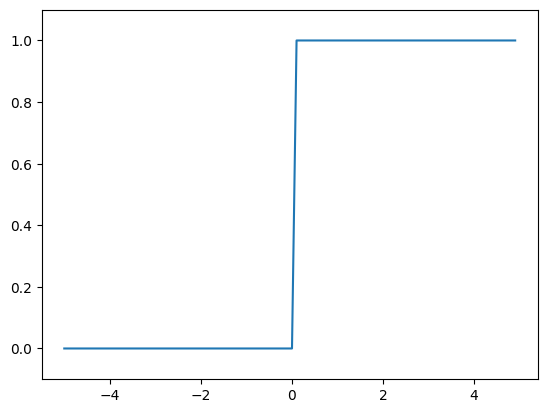

In [6]:
# ===== ステップ関数 =====
def step_function(x):
    return np.array(x>0, dtype=int)

x = np.arange(-5.0, 5.0, 0.1)
y = step_function(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1)
plt.show()

In [7]:
# ===== シグモイド関数の実装 =====
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

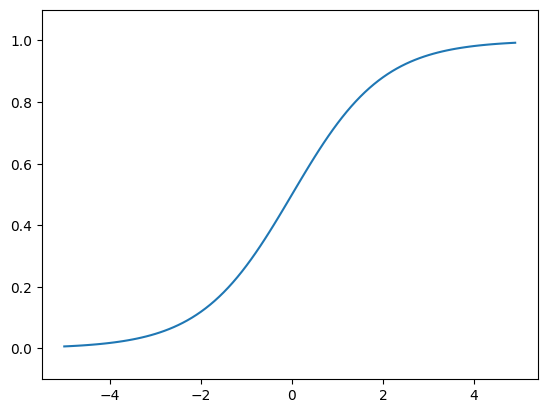

In [13]:
# ===== シグモイド関数の図子 =====
x = np.arange(-5.0, 5.0, 0.1)
y = sigmoid(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1)
plt.show()

In [14]:
# ===== ReLU関数 =====
def relu(x):
    return np.maximum(0, x)

In [18]:
# ===== Numpyを使った多次元配列計算 =====
A = np.array([1, 2, 3, 4])
print(A)

[1 2 3 4]


In [19]:
np.ndim(A)

1

In [20]:
np.shape(A)

(4,)

In [22]:
# ===== 二次元配列の場合 =====
B = np.array([[1, 2], [3, 4], [5, 6]])
print(B)

[[1 2]
 [3 4]
 [5 6]]


In [23]:
np.ndim(B)

2

In [25]:
B.shape

(3, 2)

In [27]:
A1 = np.array([[1, 2], [3, 4]])
B1 = np.array([[5, 6], [7, 8]])

np.dot(A1, B1)

array([[19, 22],
       [43, 50]])

In [31]:
A2 = np.array([[1, 2], [3, 4], [5, 6]])
B2 = np.array([7, 8])
# Numpyは１次元配列をベクトルとして特別扱いする。と覚えておくと良いようです。

np.dot(A2,B2)

array([23, 53, 83])

In [34]:
# ===== 3層ニューラルネットワークの実装 =====
X = np.array([1.0, 0.5]) # = (x1, x2)の入力
W1 = np.array([[0.1, 0.3, 0.5], [0.2, 0.4, 0.6]])
B1 = np.array([0.1, 0.2, 0.3])

print(X.shape)
print(W1.shape)
print(B1.shape)

(2,)
(2, 3)
(3,)


In [40]:
# ===== A1(1層目の重み付け和)を計算する。 =====
A1 = np.dot(X, W1) + B1
A1

array([0.3, 0.7, 1.1])

In [41]:
Z1 = sigmoid(A1)
Z1

array([0.57444252, 0.66818777, 0.75026011])

In [43]:
# ===== 1層目から2層目までの実装 =====
W2 = np.array([[0.1, 0.4], [0.2, 0.5], [0.3, 0.6 ]])
B2 = np.array([0.1, 0.2])

print(Z1.shape)
print(W2.shape)
print(B2.shape)

(3,)
(3, 2)
(2,)


In [ ]:
# ===== 2層目の出力確認 =====
A2 = np.dot(Z1, W2) + B2
Z2 = sigmoid(A2)
Z2

array([0.62624937, 0.7710107 ])

In [49]:
# ===== 3層目の実装 =====
def identity_function(x):
    return x

W3 = np.array([[0.1, 0.3], [0.2, 0.4]])
B3 = np.array([0.1, 0.2])

A3 = np.dot(Z2, W3) + B3
Y = identity_function(A3)

Y

array([0.31682708, 0.69627909])

In [52]:
# ===== これまでの実装をまとめて実装してみる =====
def init_network():
    network = {}
    network['W1'] = np.array([[0.1, 0.3, 0.5], [0.2, 0.4, 0.6]])
    network['b1'] = np.array([0.1, 0.2, 0.3])
    network['W2'] = np.array([[0.1, 0.4], [0.2, 0.5], [0.3, 0.6]])
    network['b2'] = np.array([0.1, 0.2])
    network['W3'] = np.array([[0.1, 0.3], [0.2, 0.4]])
    network['b3'] = np.array([0.1, 0.2])
    return network

def forward(network, x):
    W1, W2, W3 = network['W1'], network['W2'], network['W3']
    b1, b2, b3 = network['b1'], network['b2'], network['b3']

    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    y = identity_function(a3)

    return y

network = init_network()
x = np.array([1.0, 0.5])
y = forward(network, x)
print(y)

[0.31682708 0.69627909]
